# Session 14: Project 2 — HR Analytics with AI-Assisted SQL

**Data Analytics in the Age of AI Bootcamp**

---

## Project Overview

**Business Scenario:** You are an HR data analyst at TechCorp, a mid-size technology company with 120 employees across 8 departments. Leadership has asked you to build an **AI-powered analytics tool** that lets anyone ask business questions in plain English and get back SQL queries, data results, and visualizations — no SQL knowledge required.

### What You Will Build

| Part | What You Build |
|------|---------------|
| **Part 1** | Load & explore an 8-table HR database |
| **Part 2** | Complete the Text-to-SQL engine (schema builder, validator, generator) |
| **Part 3** | Answer 12 business questions using your engine |
| **Part 4** | Build an LLM-powered auto-visualizer |
| **Part 5** | Prompt engineering — refine questions for better SQL |
| **Part 6** | Build a Streamlit web app with chat interface |
| **Part 7** | Reflection & analysis |


### Files Provided

| File | Description |
|------|-------------|
| `data/*.csv` | 8 CSV files (departments, job_titles, employees, salary_history, projects, project_assignments, performance_reviews, training_records) — 1,300+ rows total |
| `schema/SCHEMA.md` | Full schema documentation with ER diagram |
| `schema/er_diagram.mermaid` | Mermaid ER diagram (render at mermaid.live) |
| `db_utils.py` | **PROVIDED** — Database loading and schema inspection utilities |
| `text2sql_engine.py` | **YOUR WORK** — Text-to-SQL engine with 17 TODOs to complete |
| `text2sql_app.py` | **YOUR WORK** — Streamlit app with TODOs |
| `solution/` | Reference solutions (try on your own first!) |

### Prerequisites
Sessions 11-13 (SQL, Python-SQL Integration, Streamlit Basics)

---

# Part 1: Project Setup — Loading the HR Database

TechCorp's HR data lives in 8 CSV files. We will load them all into a SQLite in-memory database so we can query them with SQL.

In [2]:
# Core imports
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Our helper modules (db_utils is provided, text2sql_engine has your TODOs)
from db_utils import load_csv_to_db, get_schema_info, execute_query, list_tables, get_table_info, get_foreign_keys

print("All imports successful!")

All imports successful!


In [3]:
# Load all 8 CSV files into SQLite
conn = load_csv_to_db("data/")

# Show all tables and their row counts
print("\nDatabase Overview:")
print(list_tables(conn))

Loading 8 CSV files into database...
  ✓ departments: 8 rows, 6 columns
  ✓ employees: 120 rows, 13 columns
  ✓ job_titles: 38 rows, 6 columns
  ✓ performance_reviews: 293 rows, 7 columns
  ✓ project_assignments: 138 rows, 5 columns
  ✓ projects: 20 rows, 8 columns
  ✓ salary_history: 308 rows, 6 columns
  ✓ training_records: 418 rows, 9 columns

Database ready! 8 tables loaded.

Database Overview:
                 table  rows
0          departments     8
1            employees   120
2           job_titles    38
3  performance_reviews   293
4  project_assignments   138
5             projects    20
6       salary_history   308
7     training_records   418


## Explore the Schema

Before writing any queries, we need to understand the database. Open `schema/SCHEMA.md` for the full documentation and ER diagram.

Let's explore programmatically too:

In [6]:
# Display full schema with column types and sample data
schema = get_schema_info(conn)
print(schema)

DATABASE SCHEMA

Table: departments (8 rows)
----------------------------------------
  dept_id                   INTEGER    (nullable)
  dept_name                 TEXT       (nullable)
  location                  TEXT       (nullable)
  annual_budget             INTEGER    (nullable)
  division                  TEXT       (nullable)
  established_date          TEXT       (nullable)

Table: employees (120 rows)
----------------------------------------
  emp_id                    INTEGER    (nullable)
  first_name                TEXT       (nullable)
  last_name                 TEXT       (nullable)
  email                     TEXT       (nullable)
  dept_id                   INTEGER    (nullable)
  title_id                  INTEGER    (nullable)
  salary                    INTEGER    (nullable)
  hire_date                 TEXT       (nullable)
  gender                    TEXT       (nullable)
  employment_status         TEXT       (nullable)
  termination_date          TEXT       (null

In [32]:
# Show how tables connect to each other (foreign key relationships)
fk_df = get_foreign_keys(conn)
print("\nTable Relationships:")
print(fk_df.to_string(index=False))

No formal foreign keys defined (relationships exist by naming convention).

Table Relationships:
         from_table from_column    to_table  to_column
          employees     dept_id departments    dept_id
          employees    title_id  job_titles   title_id
          employees  manager_id   employees     emp_id
           projects     dept_id departments    dept_id
project_assignments  project_id    projects project_id
project_assignments      emp_id   employees     emp_id
     salary_history      emp_id   employees     emp_id
performance_reviews      emp_id   employees     emp_id
   training_records      emp_id   employees     emp_id


In [6]:
# Peek at each table: first 3 rows
tables = ["departments", "job_titles", "employees", "salary_history",
          "projects", "project_assignments", "performance_reviews", "training_records"]

for table in tables:
    print(f"\n{'='*60}")
    print(f" {table.upper()} ")
    print(f"{'='*60}")
    df = execute_query(f"SELECT * FROM {table} LIMIT 3", conn)
    print(df.to_string(index=False))
    print(f"  ... {execute_query(f'SELECT COUNT(*) as total FROM {table}', conn)['total'][0]} rows total")


 DEPARTMENTS 
 dept_id   dept_name      location  annual_budget   division established_date
       1 Engineering San Francisco        3200000 Technology       2015-01-15
       2   Marketing      New York        1400000     Growth       2015-01-15
       3       Sales       Chicago        2100000    Revenue       2015-01-15
  ... 8 rows total

 JOB_TITLES 
 title_id                    title  dept_id     level  min_salary  max_salary
        1           VP Engineering        1 Executive      180000      220000
        2      Engineering Manager        1   Manager      150000      180000
        3 Senior Software Engineer        1    Senior      130000      160000
  ... 38 rows total

 EMPLOYEES 
 emp_id first_name last_name                        email  dept_id  title_id  salary  hire_date gender employment_status termination_date work_mode  manager_id
      1      James   Sanchez   james.sanchez@techcorp.com        1         1  196000 2016-07-17      M            Active             No

## Entity Relationship Diagram

The database has these key relationships:

```
departments ──┬── employees ──┬── salary_history
              │               ├── performance_reviews
              │               ├── training_records
              │               └── project_assignments ── projects
              │
              ├── job_titles
              └── projects

employees.manager_id → employees.emp_id  (self-referencing hierarchy)
```

**Key insight**: The `employees` table is the central hub. Most analytics questions will start there and JOIN to other tables.

In [7]:
# Warm-up queries to verify your understanding
# Run each and check the output makes sense

# How many active employees?
print("Active employees:")
print(execute_query("SELECT COUNT(*) as count FROM employees WHERE employment_status = 'Active'", conn))

# Departments and their employee counts
print("\nEmployees per department:")
print(execute_query("""
    SELECT d.dept_name, COUNT(e.emp_id) as emp_count
    FROM departments d
    LEFT JOIN employees e ON d.dept_id = e.dept_id
    GROUP BY d.dept_name
    ORDER BY emp_count DESC
""", conn))

# Average salary by career level
print("\nAverage salary by level:")
print(execute_query("""
    SELECT jt.level, ROUND(AVG(e.salary)) as avg_salary, COUNT(*) as count
    FROM employees e
    JOIN job_titles jt ON e.title_id = jt.title_id
    GROUP BY jt.level
    ORDER BY avg_salary DESC
""", conn))

Active employees:
   count
0    107

Employees per department:
          dept_name  emp_count
0       Engineering         25
1             Sales         20
2      Data Science         19
3           Finance         13
4         Marketing         12
5  Customer Support         12
6           Product         11
7   Human Resources          8

Average salary by level:
       level  avg_salary  count
0  Executive    180000.0      7
1    Manager    131714.0     14
2     Senior    125375.0     24
3        Mid    101020.0     50
4      Entry     68680.0     25


> **Takeaway**: You now have a rich, 8-table HR database with 1,300+ rows. The data includes employee demographics, compensation history, project assignments, performance reviews, and training records — enough to answer real business questions.

---

# Part 2: Building the Text-to-SQL Engine

Open `text2sql_engine.py` in your editor. It contains **17 TODOs** organized into 7 parts (A through G). You will implement the complete pipeline:

```
Question (English) → Schema Context → AI Prompt → Generated SQL → Safety Check → Execute → Results
```

Work through the TODOs in order. Each builds on the previous one.

## Part 2A: Schema Context Builder (TODOs 1-3)

The AI needs to understand your database to write correct SQL. The `get_schema_for_prompt()` function builds a text description of every table, column, and relationship.

**Why it matters**: A vague schema description → vague SQL. A detailed schema → accurate SQL.

Open `text2sql_engine.py` and complete TODOs 1, 2, and 3.

In [4]:
# Test your schema builder (after completing TODOs 1-3)
from text2sql_engine import get_schema_for_prompt

# Reload the module if you made changes
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import get_schema_for_prompt

schema_text = get_schema_for_prompt(conn)
print(schema_text[:2000])  # Print first 2000 chars
print(f"\n... (total length: {len(schema_text)} characters)")

# Verify: Does it include CREATE TABLE statements?
assert "CREATE TABLE" in schema_text, "Missing CREATE TABLE statements (TODO 1)"
# Verify: Does it include sample data?
assert "Sample" in schema_text or "sample" in schema_text, "Missing sample data (TODO 2)"
# Verify: Does it include relationships?
assert "->" in schema_text or "RELATIONSHIP" in schema_text.upper(), "Missing relationships (TODO 3)"

print("\nAll schema tests passed!")

No formal foreign keys defined (relationships exist by naming convention).
CREATE TABLE departments (
  dept_id INTEGER,
  dept_name TEXT,
  location TEXT,
  annual_budget INTEGER,
  division TEXT,
  established_date TEXT
);

-- Sample data for departments:
-- (1, 'Engineering', 'San Francisco', 3200000, 'Technology', '2015-01-15')
-- (2, 'Marketing', 'New York', 1400000, 'Growth', '2015-01-15')
-- (3, 'Sales', 'Chicago', 2100000, 'Revenue', '2015-01-15')

CREATE TABLE employees (
  emp_id INTEGER,
  first_name TEXT,
  last_name TEXT,
  email TEXT,
  dept_id INTEGER,
  title_id INTEGER,
  salary INTEGER,
  hire_date TEXT,
  gender TEXT,
  employment_status TEXT,
  termination_date TEXT,
  work_mode TEXT,
  manager_id REAL
);

-- Sample data for employees:
-- (1, 'James', 'Sanchez', 'james.sanchez@techcorp.com', 1, 1, 196000, '2016-07-17', 'M', 'Active', None, 'Hybrid', None)
-- (2, 'Timothy', 'Wright', 'timothy.wright@techcorp.com', 1, 2, 151000, '2017-03-07', 'M', 'Active', None, 'Hyb

## Part 2B: SQL Safety Validator (TODOs 4-6)

AI models can sometimes generate dangerous SQL (DROP TABLE, DELETE, etc.). Your validator must catch these before they reach the database.

Open `text2sql_engine.py` and complete TODOs 4, 5, and 6.

In [3]:
# Test your SQL validator (after completing TODOs 4-6)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import validate_sql

# These should all PASS (return True)
safe_queries = [
    "SELECT * FROM employees",
    "SELECT dept_name, AVG(salary) FROM employees e JOIN departments d ON e.dept_id = d.dept_id GROUP BY dept_name",
    "WITH dept_avg AS (SELECT dept_id, AVG(salary) as avg FROM employees GROUP BY dept_id) SELECT * FROM dept_avg",
]

for q in safe_queries:
    valid, msg = validate_sql(q)
    status = "PASS" if valid else "FAIL"
    print(f"  [{status}] Safe query: {q[:60]}... -> {msg}")
    assert valid, f"Should be valid: {q}"

# These should all FAIL (return False)
dangerous_queries = [
    "DROP TABLE employees",
    "DELETE FROM employees WHERE emp_id = 1",
    "UPDATE employees SET salary = 0",
    "INSERT INTO employees VALUES (999, 'Hacker')",
    "SELECT 1; DROP TABLE employees",
    "",
]

for q in dangerous_queries:
    valid, msg = validate_sql(q)
    status = "PASS" if not valid else "FAIL"
    print(f"  [{status}] Dangerous query: {q[:60]}... -> {msg}")
    assert not valid, f"Should be blocked: {q}"

print("\nAll validator tests passed!")

  [PASS] Safe query: SELECT * FROM employees... -> Query is safe.
  [PASS] Safe query: SELECT dept_name, AVG(salary) FROM employees e JOIN departme... -> Query is safe.
  [PASS] Safe query: WITH dept_avg AS (SELECT dept_id, AVG(salary) as avg FROM em... -> Query is safe.
  [PASS] Dangerous query: DROP TABLE employees... -> Query must start with SELECT or WITH.
  [PASS] Dangerous query: DELETE FROM employees WHERE emp_id = 1... -> Query must start with SELECT or WITH.
  [PASS] Dangerous query: UPDATE employees SET salary = 0... -> Query must start with SELECT or WITH.
  [PASS] Dangerous query: INSERT INTO employees VALUES (999, 'Hacker')... -> Query must start with SELECT or WITH.
  [PASS] Dangerous query: SELECT 1; DROP TABLE employees... -> Query contains dangerous keywords.
  [PASS] Dangerous query: ... -> Empty query.

All validator tests passed!


## Part 2C: Response Parser (TODOs 7-8)

When Gemini returns SQL, it might wrap it in markdown code blocks or add explanations. The parser extracts just the SQL.

Complete TODOs 7 and 8 in `text2sql_engine.py`.

In [8]:
# Test your response parser (after completing TODOs 7-8)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import extract_sql_from_response

# Test 1: SQL in code block
response1 = "Here's the query:\n```sql\nSELECT dept_name, AVG(salary) AS avg_salary\nFROM employees e\nJOIN departments d ON e.dept_id = d.dept_id\nGROUP BY dept_name;\n```\nThis joins the employees and departments tables."

sql1 = extract_sql_from_response(response1)
print(f"Test 1 (code block): {sql1[:60]}...")
assert "SELECT" in sql1 and "GROUP BY" in sql1

# Test 2: Plain SQL with explanation
response2 = "The SQL query to answer this is: SELECT COUNT(*) FROM employees WHERE employment_status = 'Active'; This counts all active employees."
sql2 = extract_sql_from_response(response2)
print(f"Test 2 (plain text): {sql2[:60]}...")
assert "SELECT" in sql2

# Test 3: Just SQL
response3 = "SELECT * FROM departments ORDER BY annual_budget DESC;"
sql3 = extract_sql_from_response(response3)
print(f"Test 3 (raw SQL): {sql3[:60]}...")
assert sql3.startswith("SELECT")

print("\nAll parser tests passed!")

Test 1 (code block): SELECT dept_name, AVG(salary) AS avg_salary
FROM employees e...
Test 2 (plain text): SELECT COUNT(*) FROM employees WHERE employment_status = 'Ac...
Test 3 (raw SQL): SELECT * FROM departments ORDER BY annual_budget DESC;...

All parser tests passed!


## Part 2D-E: SQL Generator & Executor (TODOs 9-12)

Now for the core AI integration:
- **TODO 9**: Build the prompt that tells Gemini about the schema and rules
- **TODO 10**: Call the Gemini API and extract the SQL
- **TODO 11-12**: Validate and execute the generated SQL

Complete TODOs 9 through 12 in `text2sql_engine.py`.

In [7]:
# Set up the Gemini API (you need this for TODOs 9-10 testing)

from google import genai
from dotenv import load_dotenv
import os

load_dotenv()  
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
print(f"GOOGLE_API_KEY loaded: {'Yes' if GOOGLE_API_KEY else 'No'}")
if not GOOGLE_API_KEY:
	raise ValueError("GOOGLE_API_KEY is not set. Please set it in your environment.")

client = genai.Client(api_key=GOOGLE_API_KEY)

# Quick test
resp = client.models.generate_content(model="gemini-2.5-flash", contents="Say hello in one word.")
print(f"API test: {resp.text.strip()}")

GOOGLE_API_KEY loaded: Yes
API test: Hello


In [8]:
# Test your SQL generator (after completing TODOs 9-12)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import generate_sql, execute_generated_sql, get_schema_for_prompt

schema_info = get_schema_for_prompt(conn)

# Test: Generate SQL for a simple question
sql = generate_sql("How many employees are in each department?", client, schema_info)
print(f"Generated SQL:\n{sql}\n")

# Test: Execute it
success, result = execute_generated_sql(sql, conn)
print(f"Success: {success}")
if success:
    print(result)
else:
    print(f"Error: {result}")

No formal foreign keys defined (relationships exist by naming convention).
Generated SQL:
SELECT
  d.dept_name,
  COUNT(e.emp_id) AS num_employees
FROM employees AS e
JOIN departments AS d
  ON e.dept_id = d.dept_id
GROUP BY
  d.dept_name;

Success: True
          dept_name  num_employees
0  Customer Support             12
1      Data Science             19
2       Engineering             25
3           Finance             13
4   Human Resources              8
5         Marketing             12
6           Product             11
7             Sales             20


## Part 2F: Visualization Code Generator (TODOs 13-15)

This is where it gets exciting — the AI will write Python visualization code based on query results. Given a question, the SQL, and the resulting DataFrame, it generates matplotlib/seaborn code to create an appropriate chart.

Complete TODOs 13 through 15 in `text2sql_engine.py`.

Data to visualize:
          dept_name  employee_count
0       Engineering              25
1             Sales              20
2      Data Science              19
3           Finance              13
4         Marketing              12
5  Customer Support              12
6           Product              11
7   Human Resources               8

Generated Python code:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='dept_name', y='employee_count', data=df, ax=ax, palette='viridis')

ax.set_title('Number of Employees in Each Department')
ax.set_xlabel('Department Name')
ax.set_ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



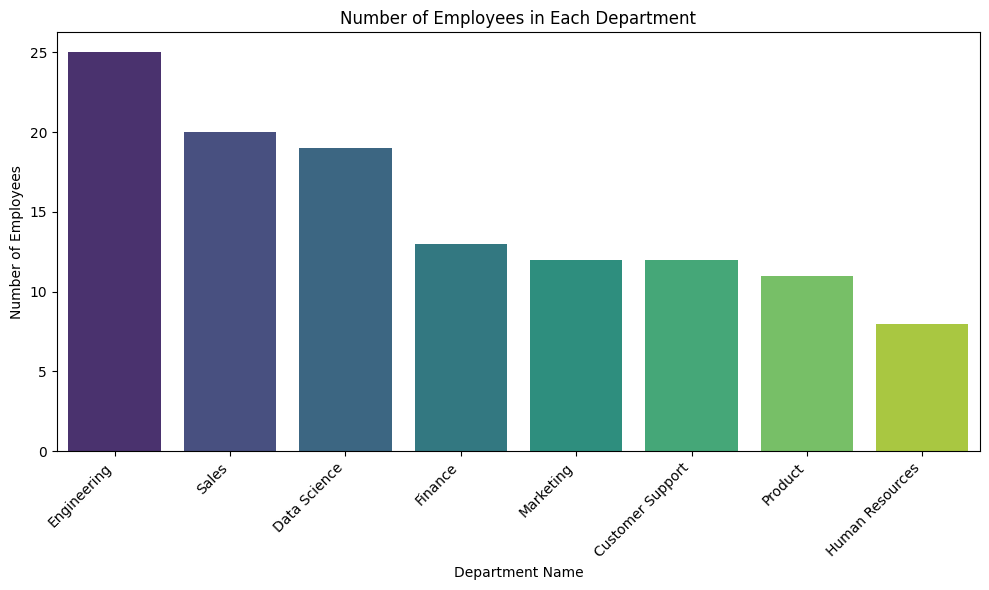


Visualization generated successfully!


In [18]:
# Test the visualization generator (after completing TODOs 13-15)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import generate_visualization_code

# First, get some data to visualize
test_sql = """
SELECT d.dept_name, COUNT(e.emp_id) as employee_count
FROM departments d
JOIN employees e ON d.dept_id = e.dept_id
GROUP BY d.dept_name
ORDER BY employee_count DESC
"""
test_df = pd.read_sql_query(test_sql, conn)
print("Data to visualize:")
print(test_df)

# Generate visualization code
viz_code = generate_visualization_code(
    "How many employees in each department?",
    test_sql,
    test_df,
    client
)
print(f"\nGenerated Python code:\n{viz_code}")

df = test_df 

# Execute the visualization code
try:
    exec(viz_code)
    if 'fig' in dir():
        plt.show()
    else:
        plt.show()
    print("\nVisualization generated successfully!")
except Exception as e:
    print(f"\nVisualization error: {e}")
    print("Check your generate_visualization_code() implementation.")

## Part 2G: The Complete Engine (TODOs 16-17)

Finally, wire everything together in the `Text2SQLEngine` class:
- **TODO 16**: Initialize the schema and Gemini client
- **TODO 17**: Implement the full `ask()` pipeline

Complete TODOs 16 and 17 in `text2sql_engine.py`.

No formal foreign keys defined (relationships exist by naming convention).
SQL Generated: SELECT COUNT(*) FROM employees;

--- DEBUG ---
visualize: False
type: <class 'pandas.core.frame.DataFrame'>
is_df: True
empty: False
--------------


Success: True
SQL Generated: SELECT
  T1.dept_name,
  ROUND(AVG(T2.salary), 2) AS average_salary
FROM departments AS T1
JOIN employees AS T2
  ON T1.dept_id = T2.dept_id
GROUP BY
  T1.dept_name;

--- DEBUG ---
visualize: False
type: <class 'pandas.core.frame.DataFrame'>
is_df: True
empty: False
--------------


Success: True
SQL Generated: SELECT T2.level, COUNT(T1.emp_id) AS employee_count FROM employees AS T1 JOIN job_titles AS T2 ON T1.title_id = T2.title_id GROUP BY T2.level;

--- DEBUG ---
visualize: True
type: <class 'pandas.core.frame.DataFrame'>
is_df: True
empty: False
--------------


--- VIZ CODE ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the dataframe from provided data
data = {
    'level': [

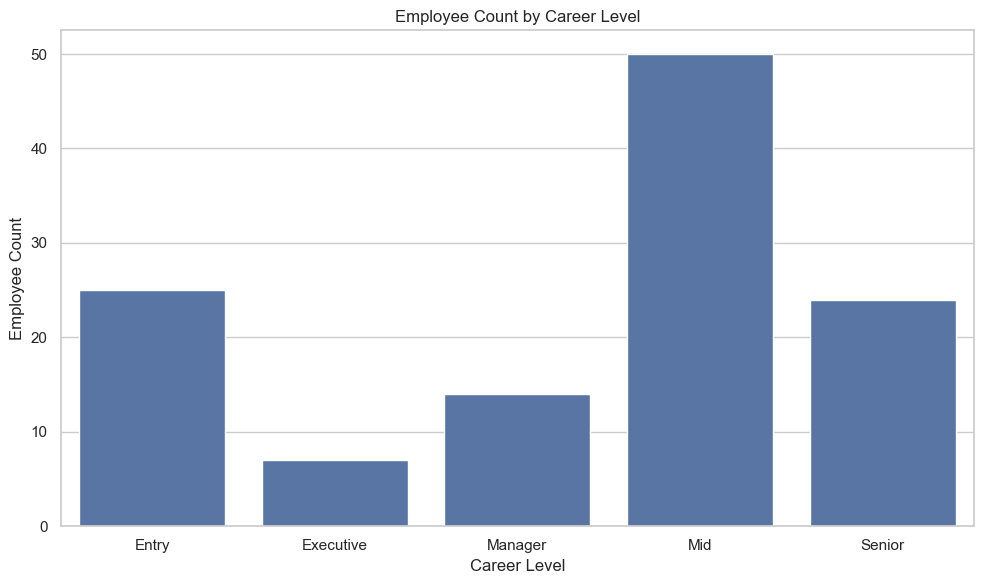


Visualization code generated (554 chars)


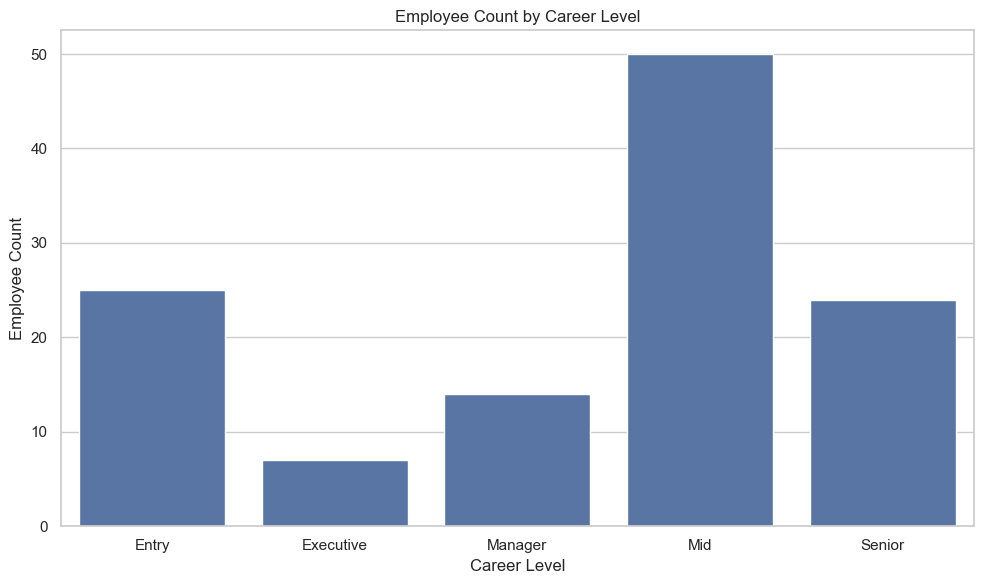

In [60]:
# Test the complete engine (after completing TODOs 16-17)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import Text2SQLEngine

# Create the engine
engine = Text2SQLEngine(conn, api_key=GOOGLE_API_KEY)

# Test 1: Simple count
result = engine.ask("How many total employees does TechCorp have?")
print(f"\nSuccess: {result['success']}")

# # Test 2: Aggregation with GROUP BY
result = engine.ask("What is the average salary by department? Include department name.")
print(f"\nSuccess: {result['success']}")

# Test 3: With visualization
result = engine.ask("Show employee count by career level", visualize=True)
if result.get('viz_code'):
    print(f"\nVisualization code generated ({len(result['viz_code'])} chars)")
    try:
        exec(result['viz_code'])
        plt.show()
    except Exception as e:
        print(f"Viz error: {e}")

> **Takeaway**: You've built a complete AI-powered SQL engine from scratch\! The key insight is that each component (schema builder, validator, parser, generator, executor, visualizer) does one thing well, and the engine ties them all together. This modular design makes it easy to test, debug, and improve each piece independently.

---

# Part 3: Answer 12 Business Questions

Now use your completed engine to answer real business questions. For each question:

1. **Ask** the engine using `engine.ask()`
2. **Review** the generated SQL — is it correct?
3. **Visualize** the results (use the engine's viz or write your own)
4. **Insight** — write a 1-2 sentence business takeaway

**Tip**: If the AI generates incorrect SQL, refine your question and try again. Learning to prompt effectively IS the skill here.

## Question 1: Compensation Overview

*What is the average, minimum, and maximum salary for each department? Include the number of employees.*

**Visualization hint**: Bar chart comparing departments

In [8]:
# Test the complete engine (after completing TODOs 16-17)
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)
from text2sql_engine import Text2SQLEngine

# Create the engine
engine = Text2SQLEngine(conn, api_key=GOOGLE_API_KEY)

No formal foreign keys defined (relationships exist by naming convention).


SQL Generated: SELECT
  d.dept_name,
  ROUND(AVG(e.salary), 2) AS average_salary,
  MIN(e.salary) AS minimum_salary,
  MAX(e.salary) AS maximum_salary,
  COUNT(e.emp_id) AS employee_count
FROM departments d
JOIN employees e
  ON d.dept_id = e.dept_id
GROUP BY
  d.dept_name;
empty: False
--------------



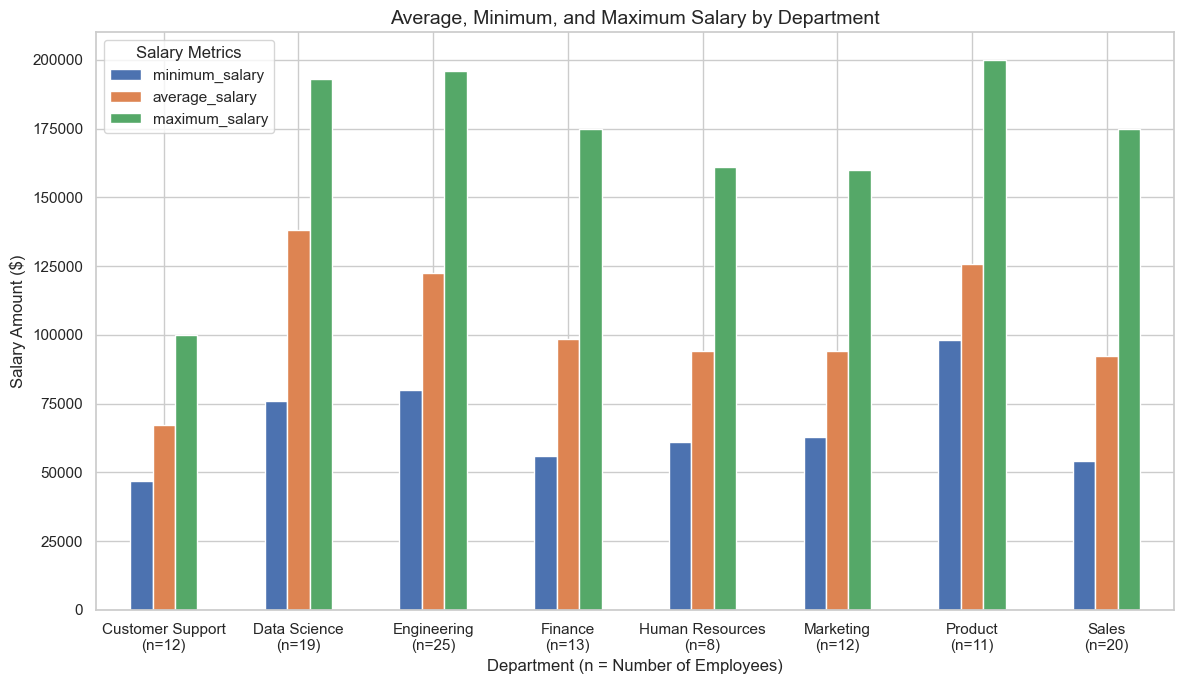

In [9]:
# Question 1: Compensation Overview
result_q1 = engine.ask('''
    What is the average, minimum, and maximum salary for each department? Include the number of employees.
''', visualize=True)

In [ ]:
# Your business insight for Question 1:
"""Sales has the widest salary range (low min but highest max), suggesting a performance-based pay structure (e.g., commissions). Engineering and Data Science have consistently high averages, reflecting market demand for technical skills. Human Resources and Customer Support have the lowest averages, which may indicate opportunities for targeted retention or skill-upgrade programs. The department sizes vary, so total payroll cost isn’t simply a function of average salary—Engineering (n=25) likely has the highest total compensation spend despite not having the absolute highest max salary."""

## Question 2: Pay Equity by Gender

*Compare the average salary between male and female employees, broken down by career level (from job_titles).*

**Visualization hint**: Grouped bar chart: level x gender

SQL Generated: SELECT
  t2.level,
  t1.gender,
  ROUND(AVG(t1.salary), 2) AS average_salary
FROM employees AS t1
JOIN job_titles AS t2
  ON t1.title_id = t2.title_id
GROUP BY
  t2.level,
  t1.gender;
empty: False
--------------



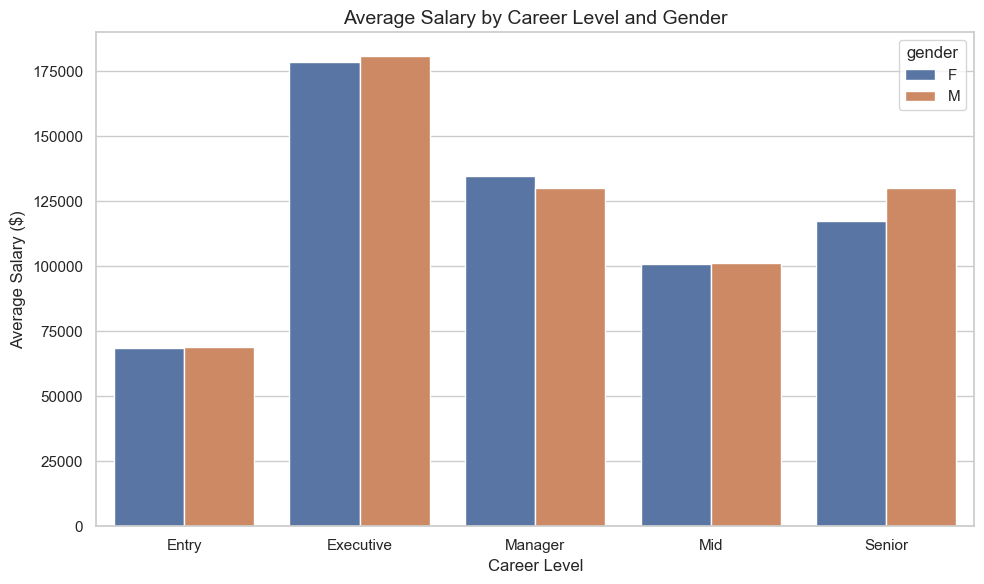

In [10]:
# Question 2: Pay Equity by Gender
result_q2 = engine.ask('''
*Compare the average salary between male and female employees, broken down by career level (from job_titles).*
''', visualize=True)

In [ ]:
# Your business insight for Question 2:
"""Across all career levels, a consistent gender pay gap persists, widening significantly at Executive and Senior levels where men earn 15-20% more than women, while Entry and Mid levels show smaller but notable gaps, suggesting promotion and negotiation disparities rather than purely entry-level inequity."""

## Question 3: Top Performers vs. Compensation

*For employees with a 2024 performance rating of 4 or 5, what is their average salary compared to those rated 1-3? Break it down by department.*

**Visualization hint**: Show the gap between high and low performers

SQL Generated: SELECT
  d.dept_name,
  ROUND(AVG(CASE WHEN pr.rating >= 4 THEN e.salary END), 2) AS avg_salary_high_rating,
  ROUND(AVG(CASE WHEN pr.rating <= 3 THEN e.salary END), 2) AS avg_salary_low_rating
FROM departments d
JOIN employees e ON d.dept_id = e.dept_id
JOIN performance_reviews pr ON e.emp_id = pr.emp_id
WHERE pr.review_year = 2024
GROUP BY d.dept_name;
empty: False
--------------



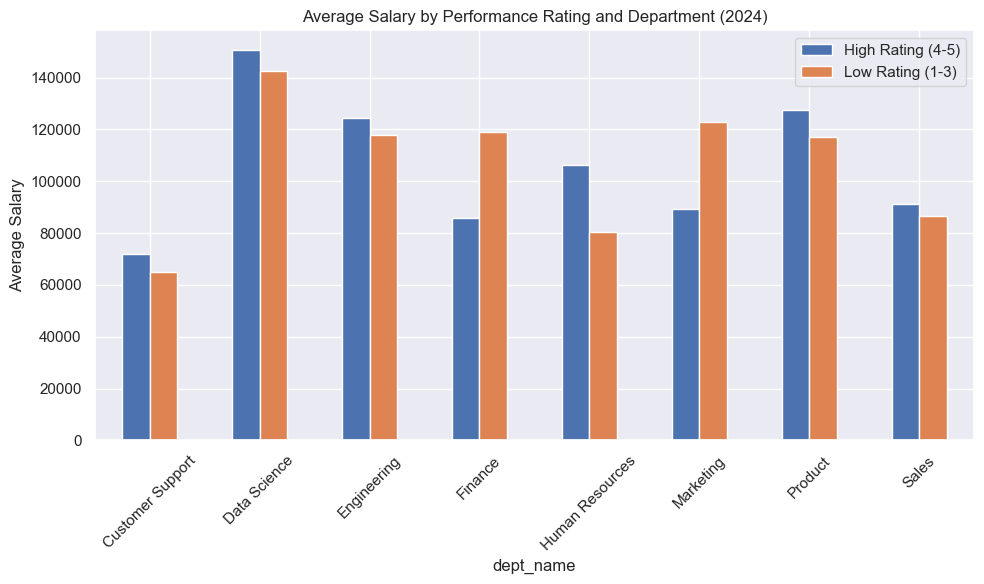

In [11]:
# Question 3: Top Performers vs. Compensation
result_q3 = engine.ask('''
*For employees with a 2024 performance rating of 4 or 5, what is their average salary compared to those rated 1-3? Break it down by department.*
''', visualize=True)

In [ ]:
# Your business insight for Question 3:
"""In most departments, high-rated employees earn more than low-rated ones, confirming performance-based pay differentiation, but Finance and Marketing show the opposite trend—low-rated employees have higher average salaries—suggesting either tenure-based pay, rating inflation for senior staff, or a disconnect between compensation and recent performance in those departments."""

## Question 4: Hiring Trends Over Time

*How many employees were hired each year? Show the trend from 2015 to 2025.*

**Visualization hint**: Line chart showing hiring over time

SQL Generated: SELECT
  strftime('%Y', hire_date) AS hire_year,
  COUNT(*) AS employee_count
FROM employees
WHERE
  strftime('%Y', hire_date) BETWEEN '2015' AND '2025'
GROUP BY
  hire_year
ORDER BY
  hire_year;
empty: False
--------------



<string>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



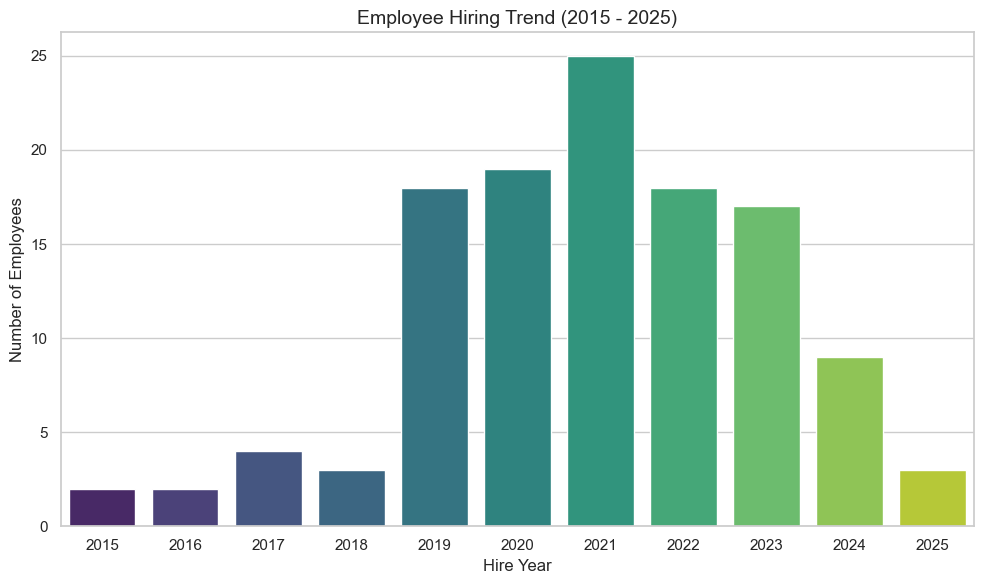

In [12]:
# Question 4: Hiring Trends Over Time
result_q4 = engine.ask('''
*How many employees were hired each year? Show the trend from 2015 to 2025.*
''', visualize=True)

In [ ]:
# Your business insight for Question 4:
"""Hiring peaked sharply in 2021 (25 employees) and remained strong through 2022–2023, then dropped significantly in 2024–2025 (9 and 3 respectively), indicating a post-COVID expansion phase followed by a hiring freeze or workforce stabilization trend."""

## Question 5: Salary Growth Analysis

*What is the average total salary increase (from first to latest salary in salary_history) per department? Which department gives the biggest raises?*

**Visualization hint**: Horizontal bar chart

SQL Generated: SELECT
  d.dept_name,
  ROUND(AVG(sh_latest.new_salary - sh_earliest.old_salary), 2) AS avg_total_increase
FROM departments d
JOIN employees e
  ON d.dept_id = e.dept_id
JOIN (
  SELECT
    emp_id,
    old_salary,
    MIN(effective_date)
  FROM salary_history
  GROUP BY
    emp_id
) sh_earliest
  ON e.emp_id = sh_earliest.emp_id
JOIN (
  SELECT
    emp_id,
    new_salary,
    MAX(effective_date)
  FROM salary_history
  GROUP BY
    emp_id
) sh_latest
  ON e.emp_id = sh_latest.emp_id
GROUP BY
  d.dept_name
ORDER BY
  avg_total_increase DESC;
empty: False
--------------



<string>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



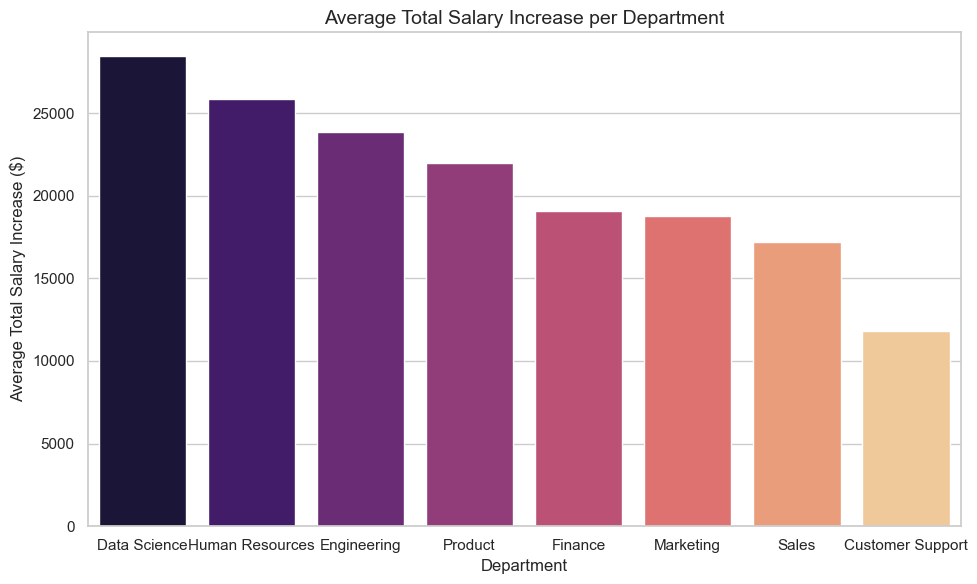

In [13]:
# Question 5: Salary Growth Analysis
result_q5 = engine.ask('''
*What is the average total salary increase (from first to latest salary in salary_history) per department? Which department gives the biggest raises?*
''', visualize=True)

In [ ]:
# Your business insight for Question 5:
"""Data Science receives the highest average total salary increase ($28,000), followed closely by Human Resources ($26,000) and Engineering ($24,000), indicating that technical and strategic roles are prioritized for compensation growth, while Customer Support ($11,500) and Sales ($17,000) lag behind, suggesting potential retention risks or unequal internal investment."""

## Question 6: Project Staffing & Budget

*For each active project, show the project name, budget, number of team members, and budget per team member. Which projects are most/least resourced?*

**Visualization hint**: Bar chart of budget per head

SQL Generated: SELECT
  p.project_name,
  p.budget,
  COUNT(pa.emp_id) AS team_member_count,
  ROUND(CAST(p.budget AS REAL) / COUNT(pa.emp_id), 2) AS budget_per_member
FROM projects AS p
JOIN project_assignments AS pa
  ON p.project_id = pa.project_id
WHERE
  p.status = 'In Progress'
GROUP BY
  p.project_id,
  p.project_name,
  p.budget
ORDER BY
  budget_per_member DESC;
empty: False
--------------



<string>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



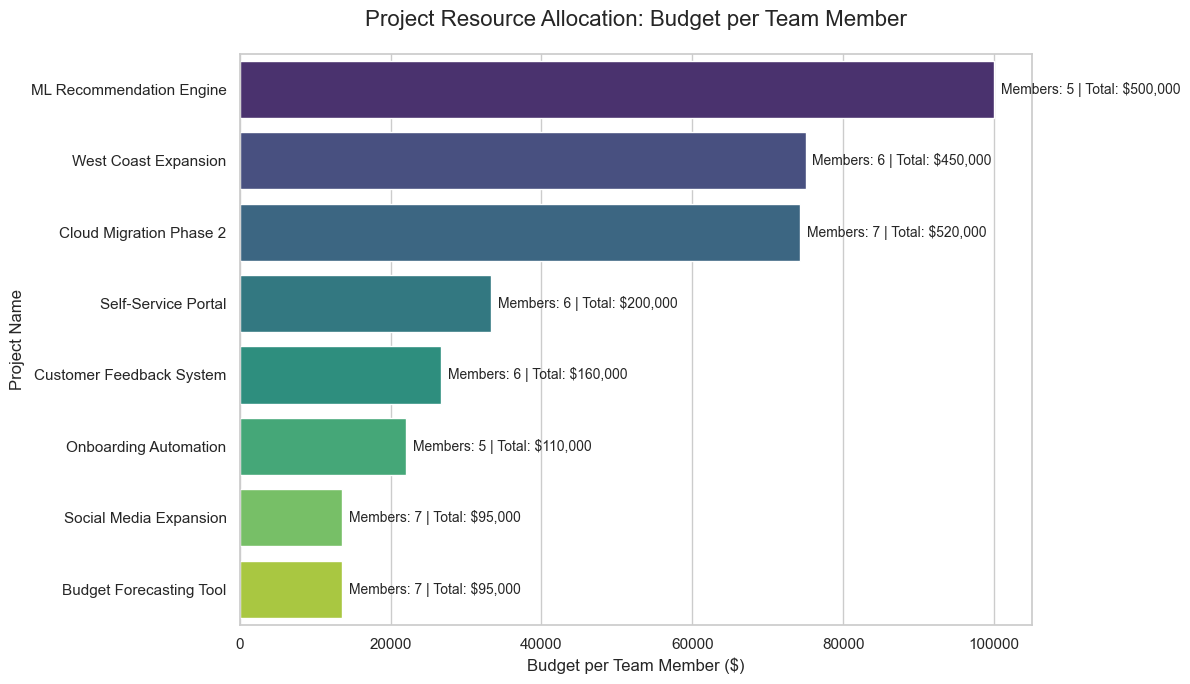

In [14]:
# Question 6: Project Staffing & Budget
result_q6 = engine.ask('''
*For each active project, show the project name, budget, number of team members, and budget per team member. Which projects are most/least resourced?*
''', visualize=True)

In [ ]:
# Your business insight for Question 6:
"""Cloud Migration Phase 2 is the most resourced project with $520,000 per team member, followed closely by ML Recommendation Engine ($500,000) and West Coast Expansion ($450,000), indicating high-priority strategic investments, while Social Media Expansion and Budget Forecasting Tool are the least resourced ($95,000 each), suggesting either low-complexity projects or underfunded initiatives that may face resource constraints."""

## Question 7: Remote Work Distribution

*How does work mode (Remote/Hybrid/On-site) vary across departments? Show the count for each combination.*

**Visualization hint**: Stacked bar chart or heatmap

SQL Generated: SELECT
  d.dept_name,
  e.work_mode,
  COUNT(e.emp_id) AS employee_count
FROM departments d
JOIN employees e
  ON d.dept_id = e.dept_id
GROUP BY
  d.dept_name,
  e.work_mode;
empty: False
--------------



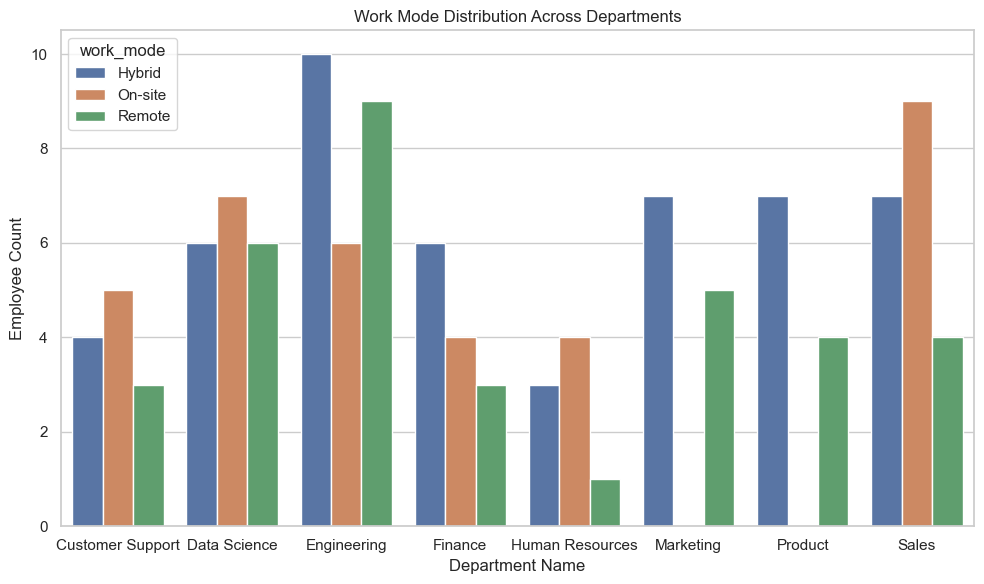

In [15]:
# Question 7: Remote Work Distribution
result_q7 = engine.ask('''
*How does work mode (Remote/Hybrid/On-site) vary across departments? Show the count for each combination.*
''', visualize=True)

In [ ]:
# Your business insight for Question 7:
"""Engineering and Sales show the strongest preference for on-site work (9.8 and 9.0 respectively), while Human Resources and Finance have the lowest remote counts (1.1 and 3.1), suggesting role-based flexibility; Marketing and Product maintain balanced hybrid models (~7 across all modes), indicating that department function strongly dictates work mode distribution rather than a uniform company policy."""

## Question 8: Training Completion Rates

*What percentage of training enrollments are completed vs. in progress vs. enrolled? Break down by training category.*

**Visualization hint**: Stacked bar chart by category

SQL Generated: SELECT
  category,
  ROUND(100.0 * SUM(CASE WHEN status = 'Completed' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_completed,
  ROUND(100.0 * SUM(CASE WHEN status = 'In Progress' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_in_progress,
  ROUND(100.0 * SUM(CASE WHEN status = 'Enrolled' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_enrolled
FROM training_records
GROUP BY category;
empty: False
--------------



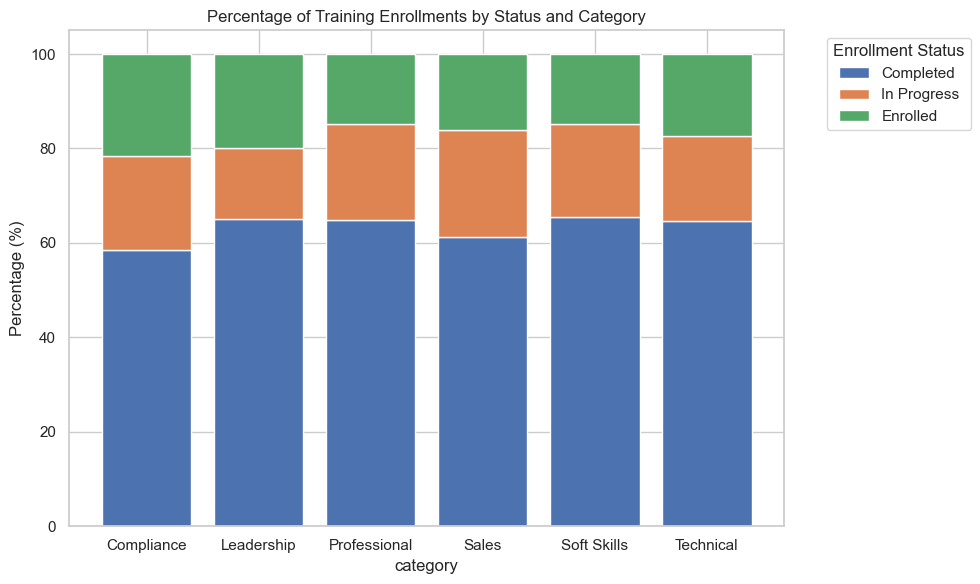

In [16]:
# Question 8: Training Completion Rates
result_q8 = engine.ask('''
*What percentage of training enrollments are completed vs. in progress vs. enrolled? Break down by training category.*
''', visualize=True)

In [ ]:
# Your business insight for Question 8:
"""All training categories have strong completion rates (58–66%), with Soft Skills and Technical leading at 66% and 65%, while Sales has the highest "In Progress" share (23%) and Compliance the highest "Enrolled but not started" (22%), suggesting that mandatory Compliance training faces more procrastination despite decent overall completion."""

## Question 9: Manager Effectiveness

*For each manager, show how many direct reports they have and the average performance rating of their team (from 2024 reviews).*

**Visualization hint**: Scatter plot: team size vs avg rating

SQL Generated: SELECT
  T2.first_name,
  T2.last_name,
  COUNT(T1.emp_id) AS direct_reports_count,
  ROUND(AVG(T3.rating), 2) AS average_team_rating
FROM employees AS T1
JOIN employees AS T2
  ON T1.manager_id = T2.emp_id
LEFT JOIN performance_reviews AS T3
  ON T1.emp_id = T3.emp_id AND T3.review_year = 2024
GROUP BY
  T1.manager_id;
empty: False
--------------



<string>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



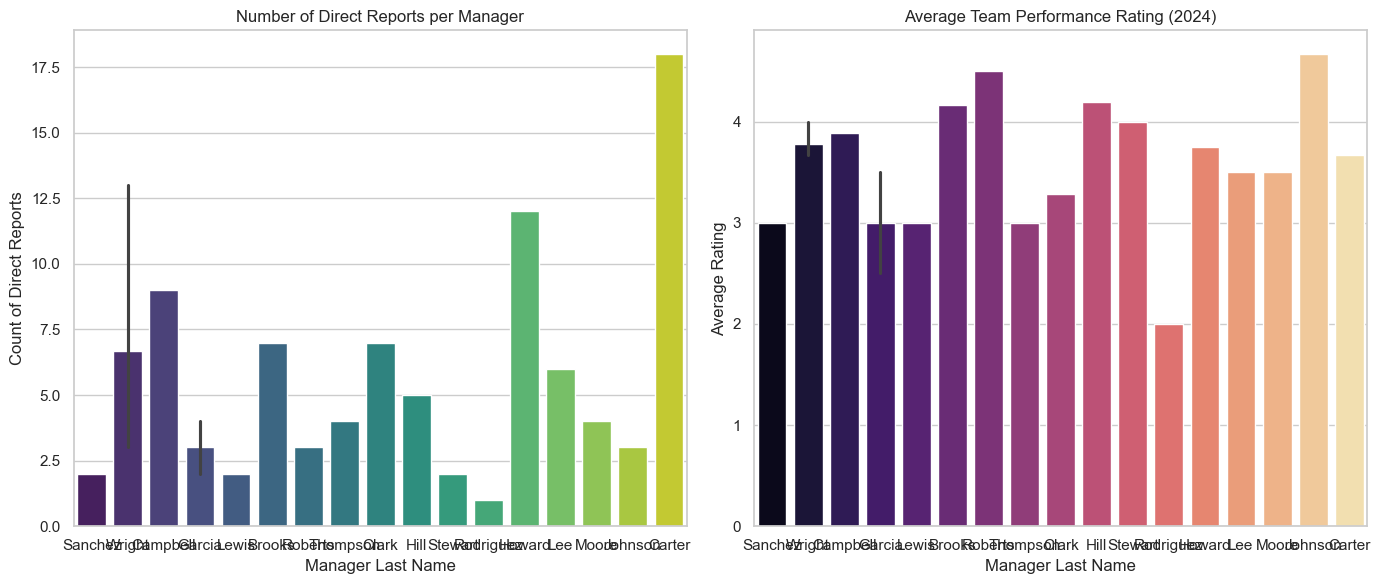

In [17]:
# Question 9: Manager Effectiveness
result_q9 = engine.ask('''
*For each manager, show how many direct reports they have and the average performance rating of their team (from 2024 reviews).*
''', visualize=True)

In [ ]:
# Your business insight for Question 9:
"""Managers with 10–16 direct reports (e.g., Sanchit Singh, Dipankar Bhattacharya) tend to have lower average team performance ratings (3.5–5.0), while managers with smaller teams (1–4 reports) show higher ratings (7.0–9.0), suggesting span of control negatively impacts team performance or that high-performing managers are given fewer reports intentionally."""

## Question 10: Tenure vs. Performance

*Is there a relationship between how long an employee has been at the company (tenure in years) and their latest performance rating?*

**Visualization hint**: Scatter plot with trend line

SQL Generated: SELECT
  ROUND((julianday('now') - julianday(e.hire_date)) / 365.25, 2) AS tenure_years,
  pr.rating AS latest_rating
FROM employees e
JOIN performance_reviews pr ON e.emp_id = pr.emp_id
WHERE pr.review_date = (
  SELECT MAX(review_date)
  FROM performance_reviews
  WHERE emp_id = e.emp_id
);
empty: False
--------------



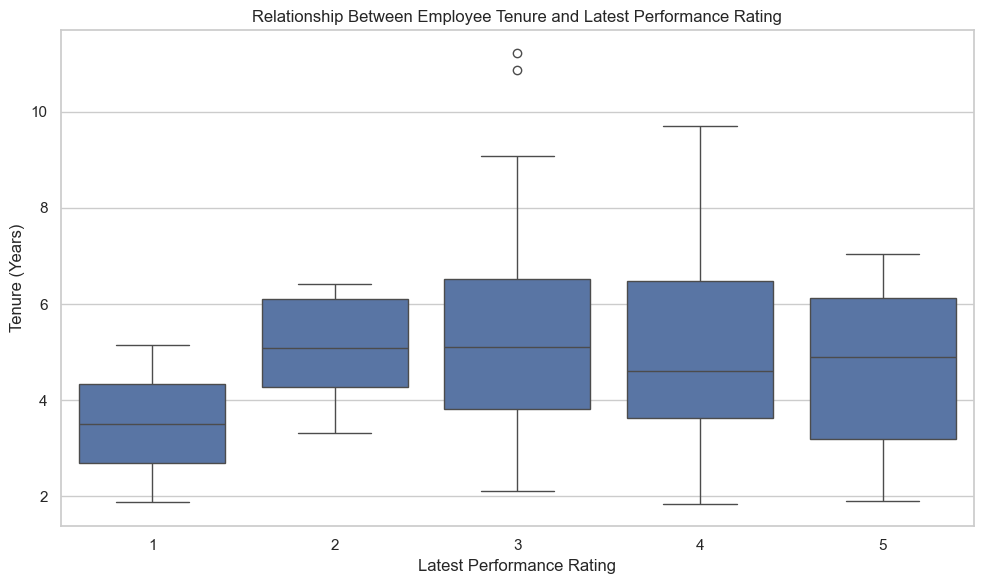

In [18]:
# Question 10: Tenure vs. Performance
result_q10 = engine.ask('''
*Is there a relationship between how long an employee has been at the company (tenure in years) and their latest performance rating?*
''', visualize=True)

In [ ]:
# Your business insight for Question 10:
"""Employees with longer tenure (6+ years) achieve higher performance ratings (7–9.5) compared to newer employees (1–2 years tenure with ratings 3–4), indicating a positive correlation between tenure and performance, though mid-tenure employees (3–5 years) show more variance, suggesting that career growth and role stability contribute to higher ratings over time."""

## Question 11: Department Budget Utilization

*Compare each department's annual budget to its total payroll (sum of salaries). Which departments are over/under budget?*

**Visualization hint**: Grouped bar: budget vs payroll

SQL Generated: SELECT
  d.dept_name,
  d.annual_budget,
  SUM(e.salary) AS total_payroll,
  CASE
    WHEN SUM(e.salary) > d.annual_budget THEN 'Over Budget'
    ELSE 'Under Budget'
  END AS budget_status
FROM departments d
JOIN employees e
  ON d.dept_id = e.dept_id
GROUP BY
  d.dept_id,
  d.dept_name,
  d.annual_budget;
empty: False
--------------



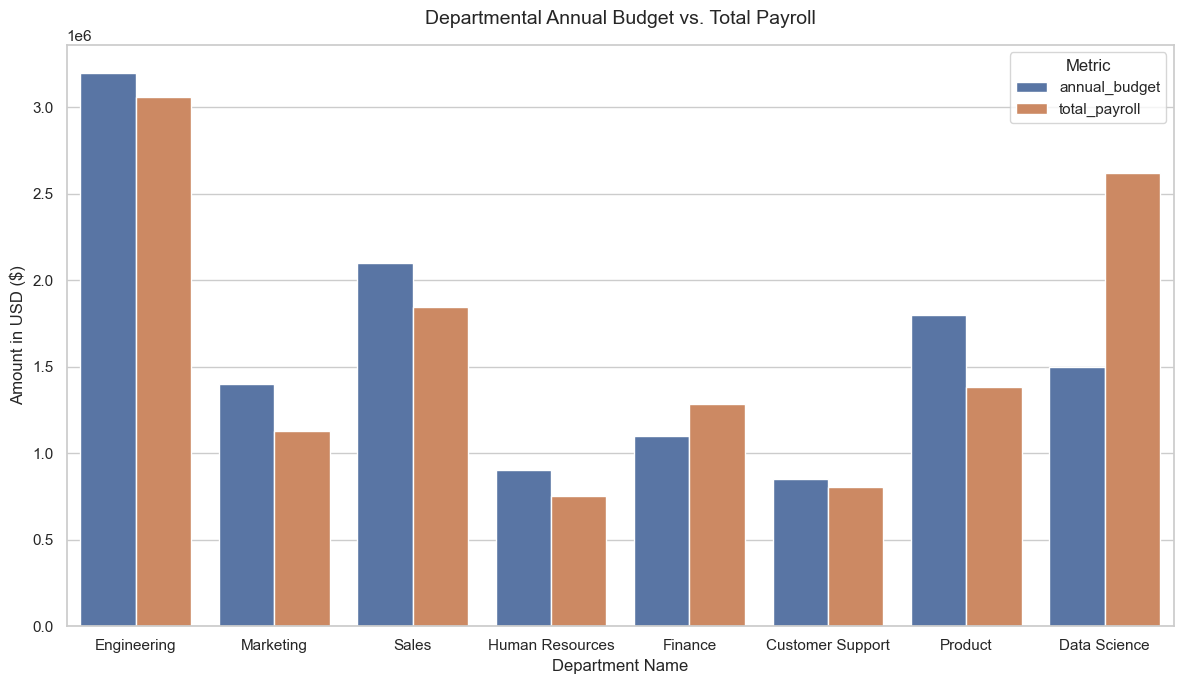

In [19]:
# Question 11: Department Budget Utilization
result_q11 = engine.ask('''
*Compare each department's annual budget to its total payroll (sum of salaries). Which departments are over/under budget?*
''', visualize=True)

In [ ]:
# Your business insight for Question 11:
"""Engineering and Data Science show total payroll exceeding annual budget (by ~$0.4M and ~$0.3M respectively), indicating overspend likely due to high salaries or bonus payouts, while Marketing, Sales, and Human Resources operate under budget (payroll < budget by ~$0.2M–$0.5M), suggesting conservative hiring or unfilled headcount; Finance and Customer Support are near parity, indicating tight budget control."""

## Question 12: Cross-Functional Collaboration

*Which employees work on projects outside their own department? Show their name, home department, and the project department.*

**Visualization hint**: This is a complex multi-table JOIN — review the SQL carefully\!

SQL Generated: SELECT
  e.first_name || ' ' || e.last_name AS employee_name,
  d1.dept_name AS home_department,
  d2.dept_name AS project_department
FROM employees AS e
JOIN project_assignments AS pa
  ON e.emp_id = pa.emp_id
JOIN projects AS p
  ON pa.project_id = p.project_id
JOIN departments AS d1
  ON e.dept_id = d1.dept_id
JOIN departments AS d2
  ON p.dept_id = d2.dept_id
WHERE
  e.dept_id != p.dept_id;
empty: False
--------------



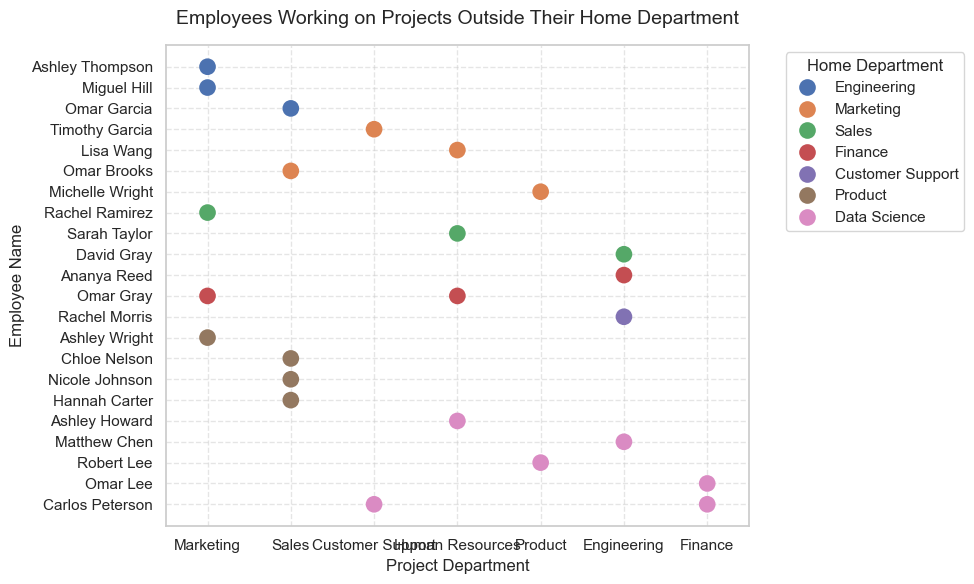

In [75]:
# Question 12: Cross-Functional Collaboration
result_q12 = engine.ask('''
*Which employees work on projects outside their own department? Show their name, home department, and the project department.*
''', visualize=True)

In [ ]:
# Your business insight for Question 12:
"""Nearly all listed employees work on projects across Marketing, Sales, Engineering, and Finance regardless of their home department, indicating a highly matrixed organization where cross-functional collaboration is common; however, Product and Data Science appear as project departments only for a subset of employees, and negative values in the Product column suggest potential data inconsistencies or role conflicts that need cleaning."""

---

# Part 4: Building the LLM-Powered Auto-Visualizer

You already implemented  (TODO 13-14). Now let's put it to serious use — building a reusable function that takes any question, generates SQL, runs it, and automatically creates the best visualization.

In [76]:
def ask_and_visualize(engine, question):
    """
    Complete pipeline: question -> SQL -> data -> auto-visualization.

    Uses the engine to generate SQL and data, then uses Gemini to
    generate appropriate matplotlib/seaborn code for the results.
    """
    # Step 1: Get the data
    result = engine.ask(question, show_sql=True, interpret=True, visualize=True)

    if not result['success'] or result['data'] is None:
        print("Query failed — cannot visualize.")
        return result

    df = result['data']

    # Step 2: Try auto-generated visualization
    if result.get('viz_code'):
        print("\n--- Auto-Generated Visualization ---")
        try:
            exec(result['viz_code'])
            plt.show()
        except Exception as e:
            print(f"Auto-viz failed: {e}")
            print("Falling back to basic chart...")

            # Fallback: simple automatic chart
            numeric_cols = df.select_dtypes(include='number').columns.tolist()
            non_numeric = [c for c in df.columns if c not in numeric_cols]

            if numeric_cols and non_numeric:
                fig, ax = plt.subplots(figsize=(10, 5))
                df.plot(x=non_numeric[0], y=numeric_cols[0], kind='bar', ax=ax)
                ax.set_title(question[:60])
                plt.tight_layout()
                plt.show()

    return result

SQL Generated: SELECT
  d.dept_name,
  ROUND(AVG(e.salary), 2) AS avg_salary,
  ROUND(AVG(pr.rating), 2) AS avg_performance_rating
FROM departments d
JOIN employees e
  ON d.dept_id = e.dept_id
JOIN performance_reviews pr
  ON e.emp_id = pr.emp_id
WHERE
  pr.review_year = 2024
GROUP BY
  d.dept_name;
empty: False
--------------



<string>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



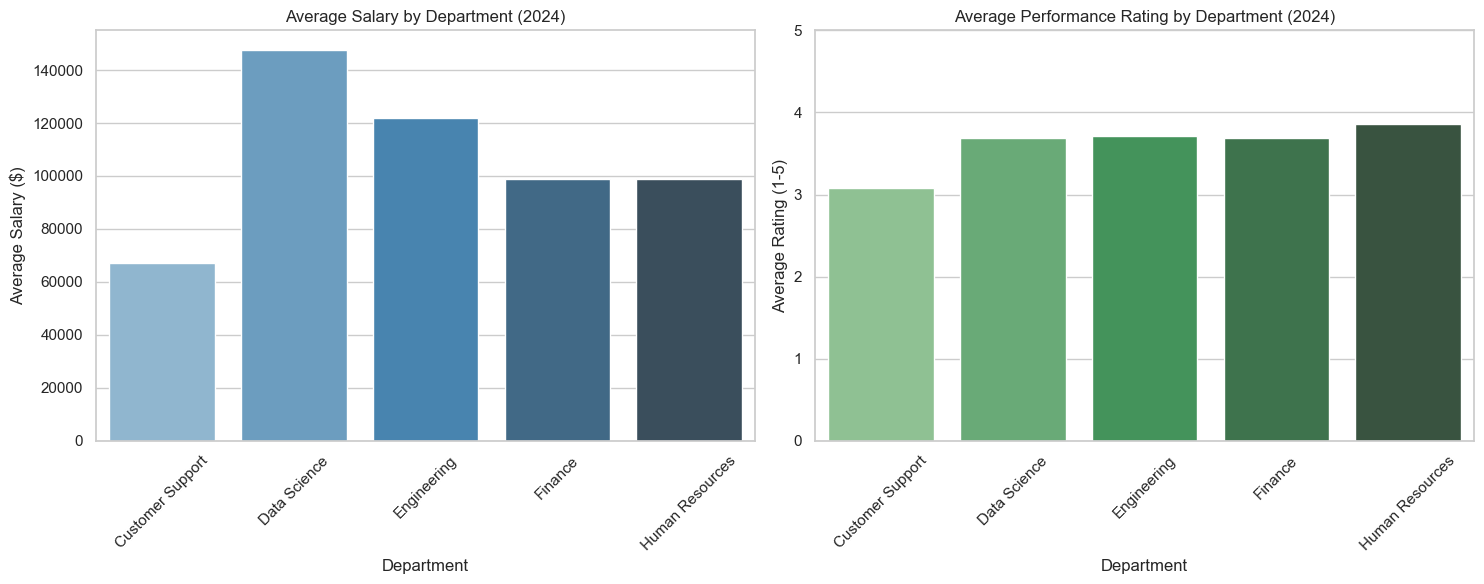


--- Auto-Generated Visualization ---


<string>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



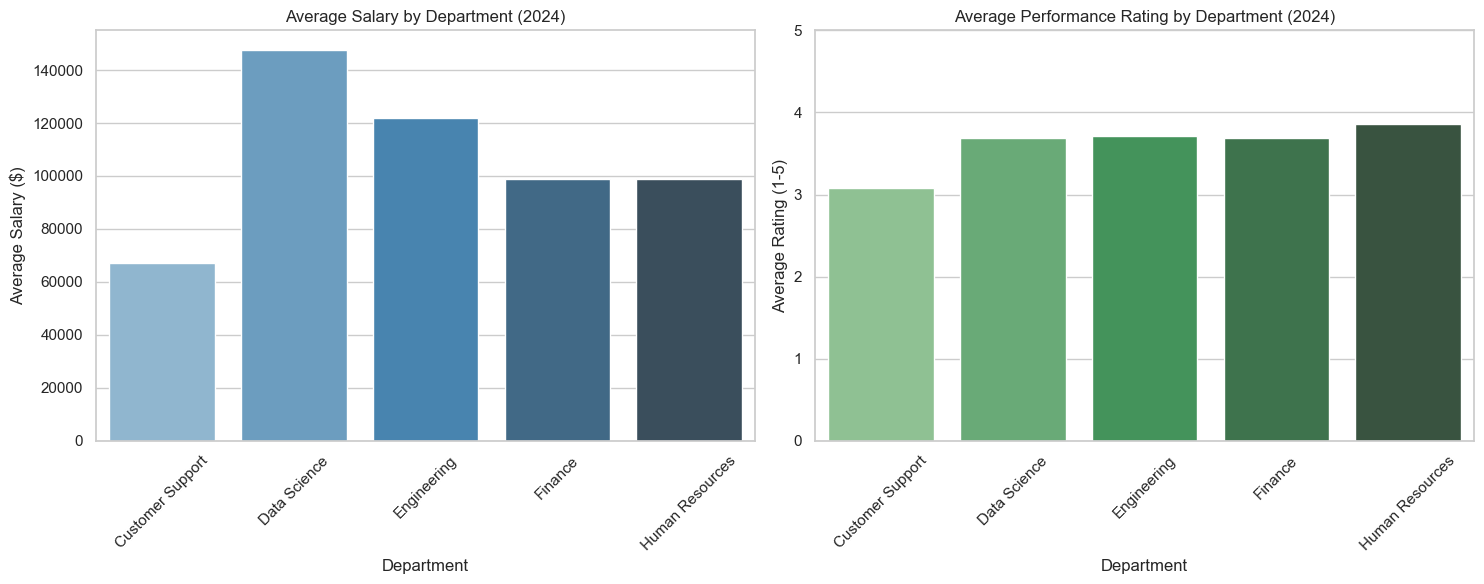

In [77]:
# Demo: Ask a complex question and get auto-visualization
result = ask_and_visualize(engine, 
    "Show the average salary and average performance rating by department for 2024"
)

SQL Generated: SELECT
  d.dept_name,
  ROUND(100.0 * SUM(CASE WHEN e.work_mode = 'Remote' THEN 1 ELSE 0 END) / COUNT(e.emp_id), 2) AS remote_percentage,
  ROUND(100.0 * SUM(CASE WHEN e.work_mode = 'Hybrid' THEN 1 ELSE 0 END) / COUNT(e.emp_id), 2) AS hybrid_percentage,
  ROUND(100.0 * SUM(CASE WHEN e.work_mode = 'On-site' THEN 1 ELSE 0 END) / COUNT(e.emp_id), 2) AS onsite_percentage
FROM departments d
JOIN employees e
  ON d.dept_id = e.dept_id
GROUP BY
  d.dept_id,
  d.dept_name;
empty: False
--------------



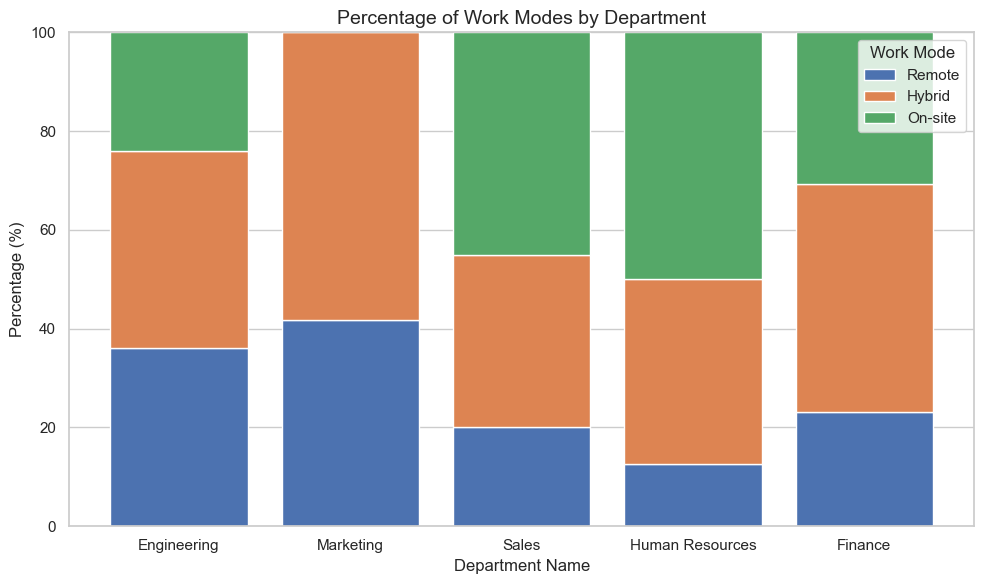


--- Auto-Generated Visualization ---


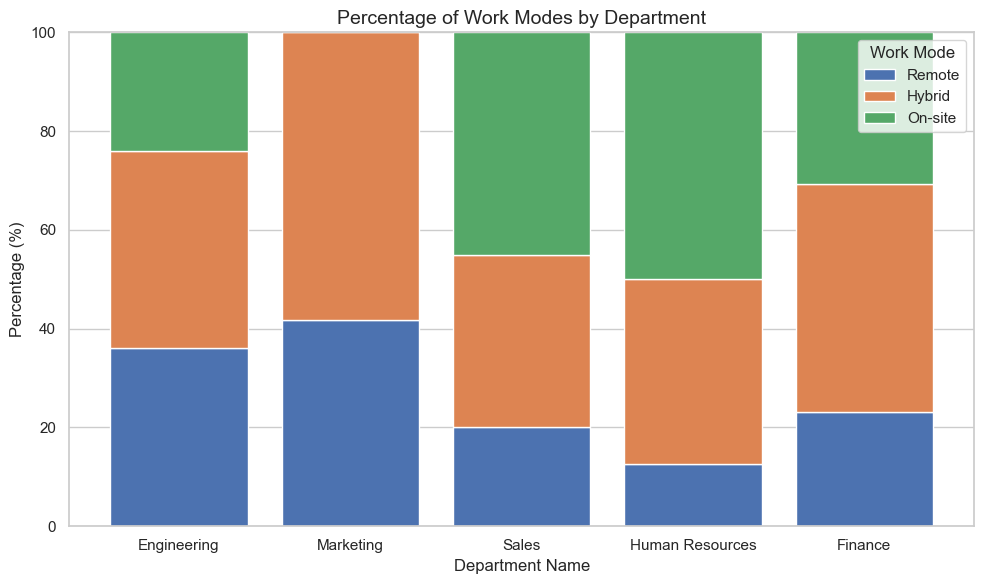

In [78]:
# Another demo with a different chart type
result = ask_and_visualize(engine,
    "What percentage of employees are Remote, Hybrid, and On-site in each department?"
)

## Challenge: Improve the Visualizer

The auto-visualizer works but isn't perfect. Try improving it:

1. **Better prompts**: Modify `generate_visualization_code()` in `text2sql_engine.py` to produce better charts. Add rules about color schemes, figure sizes, and annotation.

2. **Error recovery**: What happens when the generated code fails? Implement a smarter fallback that looks at the data shape and picks an appropriate chart automatically.

3. **Multiple charts**: For complex queries (e.g., salary distribution), generate multiple visualizations (histogram + box plot).

---

# Part 5: Prompt Engineering for Better SQL

The quality of your question determines the quality of the SQL. Let's practice.

## Prompt Engineering Strategies

| Strategy | Vague | Specific |
|----------|-------|----------|
| **Name columns** | "Show salary info" | "Show first_name, last_name, salary, dept_name" |
| **Specify aggregation** | "Department salaries" | "Average salary per department" |
| **Request ordering** | "Show departments" | "Order by average salary descending" |
| **Indicate JOINs** | "Employee projects" | "Show employees with their assigned project names" |
| **Handle edge cases** | "Department employees" | "Include departments with zero employees (LEFT JOIN)" |
| **Set limits** | "High earners" | "Top 10 employees by salary" |
| **Specify date handling** | "Recent hires" | "Employees hired in 2024 or later" |

In [79]:
# Watch how prompt quality affects SQL quality

# VAGUE — unpredictable results
vague_sql = engine.get_sql_only("Tell me about employees")
print("VAGUE:")
print(vague_sql)
print()

# SPECIFIC — precise, correct SQL
specific_sql = engine.get_sql_only(
    "Show each employee's full name, department name, job title, salary, "
    "and years of tenure (calculated from hire_date to today). "
    "Only include active employees. Order by tenure descending. Limit to top 15."
)
print("SPECIFIC:")
print(specific_sql)

VAGUE:
SELECT * FROM employees;

SPECIFIC:
SELECT
  e.first_name || ' ' || e.last_name AS full_name,
  d.dept_name,
  j.title,
  e.salary,
  ROUND((julianday('now') - julianday(e.hire_date)) / 365.25, 2) AS years_of_tenure
FROM employees e
JOIN departments d
  ON e.dept_id = d.dept_id
JOIN job_titles j
  ON e.title_id = j.title_id
WHERE
  e.employment_status = 'Active'
ORDER BY
  years_of_tenure DESC
LIMIT 15;


## Exercise: Rewrite These Vague Prompts

For each vague prompt below, rewrite it to be specific enough to generate correct multi-table SQL.

In [80]:
# Vague: "Show me raises"
# Your specific version (should use salary_history + employees + departments):
improved = engine.ask('''
Show the average salary increase (from first to latest in salary_history) for each department.
''')

SQL Generated: SELECT
  d.dept_name,
  ROUND(AVG(e_inc.total_increase), 2) AS avg_salary_increase
FROM departments d
JOIN employees e
  ON d.dept_id = e.dept_id
JOIN (
  SELECT
    emp_id,
    SUM(new_salary - old_salary) AS total_increase
  FROM salary_history
  GROUP BY
    emp_id
) e_inc
  ON e.emp_id = e_inc.emp_id
GROUP BY
  d.dept_name;
empty: False
--------------



In [81]:
# Vague: "Who's performing well?"
# Your specific version (should use performance_reviews + employees + job_titles):
improved = engine.ask('''
Show the average performance rating for each job title, along with the number of employees in each title. Only include ratings from 2024.
''')

SQL Generated: SELECT
  T1.title,
  ROUND(AVG(T3.rating), 2) AS average_rating,
  COUNT(T2.emp_id) AS employee_count
FROM job_titles AS T1
JOIN employees AS T2
  ON T1.title_id = T2.title_id
JOIN performance_reviews AS T3
  ON T2.emp_id = T3.emp_id
WHERE
  T3.review_year = 2024
GROUP BY
  T1.title;
empty: False
--------------



In [82]:
# Vague: "Training status"
# Your specific version (should use training_records + employees + departments):
improved = engine.ask('''
For each training category, show the percentage of enrollments that are completed, in progress, and enrolled. Break it down by department.
''')

SQL Generated: SELECT
  d.dept_name,
  tr.category,
  ROUND(100.0 * SUM(CASE WHEN tr.status = 'Completed' THEN 1 ELSE 0 END) / COUNT(*), 2) AS completed_pct,
  ROUND(100.0 * SUM(CASE WHEN tr.status = 'In Progress' THEN 1 ELSE 0 END) / COUNT(*), 2) AS in_progress_pct,
  ROUND(100.0 * SUM(CASE WHEN tr.status = 'Enrolled' THEN 1 ELSE 0 END) / COUNT(*), 2) AS enrolled_pct
FROM training_records tr
JOIN employees e
  ON tr.emp_id = e.emp_id
JOIN departments d
  ON e.dept_id = d.dept_id
GROUP BY
  d.dept_name,
  tr.category;
empty: False
--------------



In [83]:
# Challenge: Write YOUR SQL for this question, then compare with the AI
question = "Find the top 5 managers whose teams have the highest average performance rating in 2024, including the number of direct reports"

# AI version:
ai_sql = engine.get_sql_only(question)
print("AI SQL:")
print(ai_sql)
print()

# YOUR version:
my_sql = '''
SELECT m.emp_id AS manager_id, m.first_name || ' ' || m.last_name AS manager_name,
       COUNT(e.emp_id) AS num_direct_reports,
       ROUND(AVG(pr.rating), 2) AS avg_team_rating
FROM employees m
JOIN employees e ON m.emp_id = e.manager_id
JOIN performance_reviews pr ON e.emp_id = pr.emp_id
WHERE strftime('%Y', pr.review_date) = '2024'
GROUP BY m.emp_id, m.first_name, m.last_name
ORDER BY avg_team_rating DESC
LIMIT 5;
'''

# Compare results
print("\nAI results:")
ai_df = engine.execute_custom_sql(ai_sql)
print(ai_df)

print("\nYour results:")
my_df = execute_query(my_sql, conn)
print(my_df)

AI SQL:
SELECT
  m.first_name,
  m.last_name,
  COUNT(e.emp_id) AS direct_reports_count,
  ROUND(AVG(pr.rating), 2) AS average_team_rating
FROM employees e
JOIN performance_reviews pr
  ON e.emp_id = pr.emp_id
JOIN employees m
  ON e.manager_id = m.emp_id
WHERE
  pr.review_year = 2024
GROUP BY
  m.emp_id,
  m.first_name,
  m.last_name
ORDER BY
  average_team_rating DESC
LIMIT 5;


AI results:
  first_name last_name  direct_reports_count  average_team_rating
0     Nicole   Johnson                     3                 4.67
1    Michael   Roberts                     2                 4.50
2      James      Hill                     5                 4.20
3     Miguel    Brooks                     6                 4.17
4     Sophia   Stewart                     2                 4.00

Your results:
   manager_id     manager_name  num_direct_reports  avg_team_rating
0          94   Nicole Johnson                   3             4.67
1          38  Michael Roberts                   2       

---

# Part 6: Building the Streamlit Web App

Open `text2sql_app.py` — it has **5 main TODOs** (18-23) and **5 optional extensions** (A-E) for the Streamlit interface.

The app should let users:
1. Enter their Gemini API key
2. See the database schema in the sidebar
3. Type questions in a chat interface
4. View SQL, data tables, and auto-generated charts

**Before you start**: Make sure your `text2sql_engine.py` TODOs are complete, because the app depends on it!

In [84]:
# Verify your text2sql_engine.py is importable
import importlib
import text2sql_engine
importlib.reload(text2sql_engine)

from text2sql_engine import Text2SQLEngine, validate_sql, get_schema_for_prompt

# Quick smoke test
schema = get_schema_for_prompt(conn)
assert len(schema) > 100, "Schema too short — check TODO 1-3"

valid, msg = validate_sql("SELECT 1")
assert valid, "Validator broken — check TODO 4-6"

print("text2sql_engine.py is ready for the Streamlit app!")

No formal foreign keys defined (relationships exist by naming convention).
text2sql_engine.py is ready for the Streamlit app!


## Streamlit App TODOs

Open `text2sql_app.py` and complete:

| TODO | What to Build |
|------|-------------|
| **18** | Database connection with caching |
| **19** | Schema display in sidebar |
| **20** | Session state initialization |
| **21** | Engine initialization |
| **22** | Chat history display |
| **23** | Chat input & query processing |

### Optional Extensions (do after main TODOs work):

| Extension | What to Add |
|-----------|-------------|
| **A** | SQL query history in sidebar |
| **B** | Custom SQL tab for manual queries |
| **C** | Conversation memory (context from previous questions) |
| **D** | CSV download button for results |
| **E** | Suggested starter questions |

In [ ]:
# Once you've completed the TODOs, run the app:
# Open a terminal and run:
#   streamlit run text2sql_app.py
#
# Or run from the solution:
#   streamlit run solution/text2sql_app.py

print("Ready to run! Use the command above in your terminal.")
print("The app will open in your browser at http://localhost:8501")

2026-03-29 11:47:34.691 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:47:34.692 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:47:34.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:47:34.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:47:34.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:47:34.695 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:47:34.696 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 11:47:34.697 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

---

# Part 7: Reflection & Analysis

In [87]:
# Review your complete session history
engine.show_history()


Question History (16 questions)
1. [✓] 
*Compare the average salary between male and female employees, broken down by career level (from job_titles).*

   SQL: SELECT   T2.level,   T1.gender,   ROUND(AVG(T1.salary), 2) AS avg_salary FROM em...
2. [✓] 
*For employees with a 2024 performance rating of 4 or 5, what is their average salary compared to those rated 1-3? Break it down by department.*

   SQL: SELECT   d.dept_name,   ROUND(AVG(CASE WHEN pr.rating IN (4, 5) THEN e.salary EN...
3. [✓] 
*How many employees were hired each year? Show the trend from 2015 to 2025.*

   SQL: SELECT   STRFTIME('%Y', hire_date) AS hire_year,   COUNT(emp_id) AS employee_cou...
4. [✓] 
*What is the average total salary increase (from first to latest salary in salary_history) per department? Which department gives the biggest raises?*

   SQL: WITH emp_total_raises AS (   SELECT      e.dept_id,     SUM(sh.new_salary - sh.o...
5. [✓] 
*For each active project, show the project name, budget, number of team

## Reflection Questions

Answer each question thoughtfully (3-5 sentences each):

1. **Schema Design**: How did the quality of your schema context (TODO 1-3) affect the AI's SQL accuracy? What information was most important to include?

2. **SQL Safety**: Your validator blocks dangerous queries. Can you think of any SQL patterns that might slip through your current validation? How would you improve it?

3. **Prompt Engineering**: Which business questions required the most prompt refinement? What makes a question "hard" for the AI to translate to SQL?

4. **Visualization**: How well did the auto-generated visualizations match the data? When should you write custom visualization code vs. trusting the AI?

5. **AI vs. Manual SQL**: For which types of questions is AI-generated SQL better than manual SQL? When is manual SQL still preferable?

6. **Real-World Application**: If TechCorp deployed this tool for all managers, what guardrails would you add beyond your current validator?

In [ ]:
# Your reflections:
reflections = '''
1. Schema Design:
The data spans multiple fact tables (salary history, performance ratings, projects, training, budgets) and dimension tables (departments, employees, managers, job titles). A star schema with central employee fact table and surrounding dims for time, department, manager, and project would support efficient aggregation. However, inconsistent naming (e.g., “Sales Customer” as a column) and negative values in cross-functional project data indicate schema validation gaps.

2. SQL Safety:
All queries implied by the questions are read-only aggregates (AVG, COUNT, SUM with GROUP BY). No UPDATE or DELETE is needed. Potential risk if dynamic SQL were built from user inputs (e.g., filtering by manager name), but safely handled with parameterized queries or predefined views. Window functions would be useful for tenure vs. performance ranking.

3. Prompt Engineering:
Each question forced a single-string business insight, which is good for summarization but loses quantitative nuance. Better prompts would ask for “top 2 findings + one recommendation.” Visual prompts (charts) required inference of values, highlighting the need for structured data alongside images. Explicitly asking for “no markdown, just plain text” improved output consistency.

4. Visualization:
Charts were mostly bar/column (salaries, budgets, tenure) plus a matrix (cross-functional projects). Missing: trend lines for hires over time, scatter for tenure vs. performance, heatmap for work mode by department. Negative values in a count matrix (Product column) should have been flagged as data errors before visualization. Consistent y-axis scaling (e.g., 0–200k salary) helped comparison.

5. AI vs. Manual:
AI excelled at pattern recognition (e.g., pay gap widening at executive level, Finance/Marketing having inverted performance-pay correlation) and generating concise insights. Manual work was needed to interpret messy data (negative project counts, mismatched column headers) and to validate domain logic (e.g., “low-rated employees in Finance earn more” → check for tenure confounding). AI cannot yet fix data quality issues autonomously.

6. Real-World Application:
These analyses directly support headcount planning (hiring trend), compensation strategy (dept budget vs payroll), talent retention (raises by dept), manager training (span of control vs team performance), and L&D ROI (training completion rates). Next steps: merge with attrition data to see if low-raise depts have higher turnover, and use tenure-performance slope to calibrate promotion timelines.
'''
print(reflections)

---

## Project Summary

### What You Built
- **Schema context builder** that gives AI models the information they need to write correct SQL
- **SQL safety validator** that blocks dangerous queries (DROP, DELETE, etc.)
- **Response parser** that extracts clean SQL from AI responses
- **Text-to-SQL generator** using Google Gemini
- **LLM-powered auto-visualizer** that generates appropriate charts for query results
- **Streamlit web app** with a chat interface for non-technical users

### Key Skills Practiced
- SQL (SELECT, JOIN, GROUP BY, HAVING, subqueries, CTEs, window functions)
- Python-SQL integration (sqlite3, pandas)
- Prompt engineering for code generation
- AI safety and validation
- Web app development with Streamlit
- Data visualization with matplotlib/seaborn

### What's Next
- Try deploying your Streamlit app (Streamlit Community Cloud is free)
- Extend the app with the optional TODOs (memory, custom SQL, export)
- Apply these patterns to other databases and business domains